# Notebook 1: Exploratory Data Analysis

**DATA5322: Statistical Machine Learning II**  
Seattle University, Spring 2026  
Team: Ruman Sidhu, Paul Skentzos, Hamda Hassan

---

## Goals
- Load and inspect all four datasets (BC-TCGA, GSE2034, GSE25066, Simulation)
- Confirm dimensions, data types, and assess missing values
- Visualize gene expression distributions and compare scales across datasets
- Decide which dataset to use for the main analysis and document the reasoning
- Apply preprocessing and save the cleaned matrix for downstream notebooks

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 12)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')

DATA_DIR  = Path('../data')
PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(exist_ok=True)

---
## 1. Load All Datasets

Each file is tab-separated.  
- Row 0 is the header: `Hybridization REF` followed by sample IDs.  
- Subsequent rows: gene name (index) followed by expression values.  
- We transpose immediately so the working convention is samples x genes.

In [25]:
def load_expression(path: Path) -> pd.DataFrame:
    """Load a tab-separated expression file and return a (samples x genes) DataFrame."""
    df = pd.read_csv(path, sep='\t', index_col=0)
    df.index.name = 'Gene'
    return df.T  # transpose: rows=samples, cols=genes

datasets = {
    'BC-TCGA Tumor':     load_expression(DATA_DIR / 'BC-TCGA'        / 'BC-TCGA-Tumor.txt'),
    'BC-TCGA Normal':    load_expression(DATA_DIR / 'BC-TCGA'        / 'BC-TCGA-Normal.txt'),
    'GSE2034 Tumor':     load_expression(DATA_DIR / 'GSE2034'        / 'GSE2034-Tumor.txt'),
    'GSE2034 Normal':    load_expression(DATA_DIR / 'GSE2034'        / 'GSE2034-Normal.txt'),
    'GSE25066 Tumor':    load_expression(DATA_DIR / 'GSE25066'       / 'GSE25066-Tumor.txt'),
    'GSE25066 Normal':   load_expression(DATA_DIR / 'GSE25066'       / 'GSE25066-Normal.txt'),
    'Simulation Tumor':  load_expression(DATA_DIR / 'Simulation-Data'/ 'Simulation-Data-Tumor.txt'),
    'Simulation Normal': load_expression(DATA_DIR / 'Simulation-Data'/ 'Simulation-Data-Normal.txt'),
}

print(f"{'Dataset':<25} {'Samples':>8} {'Genes':>8}")
print('-' * 44)
for name, df in datasets.items():
    print(f"{name:<25} {df.shape[0]:>8} {df.shape[1]:>8}")

Dataset                    Samples    Genes
--------------------------------------------
BC-TCGA Tumor                  529    17814
BC-TCGA Normal                  61    17814
GSE2034 Tumor                  179    12634
GSE2034 Normal                 107    12634
GSE25066 Tumor                 392    12634
GSE25066 Normal                100    12634
Simulation Tumor               100    10000
Simulation Normal              100    10000


---
## 2. Spot-Check the Primary Dataset

In [26]:
tcga = datasets['BC-TCGA Tumor']
print('Shape (samples x genes):', tcga.shape)
tcga.iloc[:5, :6]

Shape (samples x genes): (529, 17814)


Gene,ELMO2,CREB3L1,RPS11,PNMA1,MMP2,C10orf90
TCGA-AO-A03P-01A-11R-A00Z-07,1.2194,-0.1522,2.1934,-0.2188,-0.1487,-1.9550
TCGA-A8-A06T-01A-11R-A00Z-07,0.4303,0.4445,-0.1006,-0.1675,-0.2060,-2.0185
TCGA-A8-A07F-01A-11R-A00Z-07,0.4398,1.8822,0.0556,-0.0260,0.9702,-3.2575
TCGA-A8-A081-01A-11R-A00Z-07,1.2427,1.7810,0.2695,0.1497,-1.0732,-2.7407
TCGA-A8-A08C-01A-11R-A00Z-07,-0.2283,0.5335,0.7224,0.4275,-0.2837,-1.8480


---
## 2a. Why Log2 Normalization?

Before diving into distributions, it is worth understanding why this data is expressed as log2 ratios rather than raw measurement values.

Gene expression measurements in this dataset span several orders of magnitude. A highly active gene might register a value thousands of times larger than a nearly inactive one. Working directly with raw values on that scale creates two problems:

1. **Skewed distributions:** A small number of high-signal features would dominate any variance-based analysis (PCA, clustering), drowning out meaningful variation in moderate-signal features.

2. **Asymmetric changes:** A value doubling (+100%) and a value halving (-50%) are equivalent in magnitude as changes, but they do not look symmetric on a linear scale. On a log2 scale they become +1 and -1, which is the correct symmetric representation.

Log2 transformation compresses the dynamic range, makes the distribution more symmetric, and puts all features on a more comparable scale. This is standard preprocessing for this type of high-dimensional measurement data.

The TCGA dataset here has already been log2-transformed and centered (each gene mean-subtracted across the cohort), which is why values cluster near zero. No additional log transformation is needed.

---
## 3. Missing Value Assessment

The BC-TCGA Tumor file encodes some missing measurements as the literal string `null`
(not an empty cell). Pandas automatically reads this as `NaN`, so `isnull()` catches it correctly.

In [27]:
print(f"{'Dataset':<25} {'Missing cells':>15} {'% Missing':>12}")
print('-' * 54)
for name, df in datasets.items():
    total   = df.size
    missing = df.isnull().sum().sum()
    print(f"{name:<25} {missing:>15,} {missing/total*100:>11.4f}%")

Dataset                     Missing cells    % Missing
------------------------------------------------------
BC-TCGA Tumor                       1,497      0.0159%
BC-TCGA Normal                        198      0.0182%
GSE2034 Tumor                           0      0.0000%
GSE2034 Normal                          0      0.0000%
GSE25066 Tumor                          0      0.0000%
GSE25066 Normal                         0      0.0000%
Simulation Tumor                        0      0.0000%
Simulation Normal                       0      0.0000%


In [28]:
# Drill into the BC-TCGA Tumor nulls
tcga_missing       = tcga.isnull()
genes_with_nulls   = tcga_missing.any(axis=0).sum()
samples_with_nulls = tcga_missing.any(axis=1).sum()
total_nulls        = tcga_missing.sum().sum()

print(f'Total null values  : {total_nulls:,}  ({total_nulls / tcga.size * 100:.4f}% of all cells)')
print(f'Genes affected     : {genes_with_nulls:,} / {tcga.shape[1]:,} ({genes_with_nulls/tcga.shape[1]*100:.1f}%)')
print(f'Samples affected   : {samples_with_nulls:,} / {tcga.shape[0]:,} ({samples_with_nulls/tcga.shape[0]*100:.1f}%)')

null_per_gene   = tcga_missing.sum(axis=0)
null_per_sample = tcga_missing.sum(axis=1)

print('\nTop 10 genes by null count:')
print(null_per_gene[null_per_gene > 0].sort_values(ascending=False).head(10).to_string())
print('\nTop 10 samples by null count:')
print(null_per_sample[null_per_sample > 0].sort_values(ascending=False).head(10).to_string())

Total null values  : 1,497  (0.0159% of all cells)
Genes affected     : 487 / 17,814 (2.7%)
Samples affected   : 280 / 529 (52.9%)

Top 10 genes by null count:
Gene
LCE1B        16
LHX5         16
ADAM5P       14
LOC646982    14
CCDC140      13
OR4F15       13
RPTN         13
OR1J4        13
DEFB127      12
RPE65        12

Top 10 samples by null count:
TCGA-BH-A0HU-01A-11R-A034-07    57
TCGA-B6-A0IE-01A-11R-A034-07    43
TCGA-AR-A1AU-01A-11R-A12P-07    38
TCGA-BH-A0HQ-01A-11R-A034-07    36
TCGA-AO-A0J9-01A-11R-A034-07    32
TCGA-AN-A0FD-01A-11R-A034-07    26
TCGA-E2-A1B6-01A-31R-A12P-07    24
TCGA-BH-A0BF-01A-21R-A12P-07    24
TCGA-B6-A0IO-01A-11R-A034-07    24
TCGA-B6-A0I6-01A-11R-A034-07    22


---
## 4. Understanding the Missing Data

---

When we examined the BC-TCGA dataset carefully, we found that roughly 1,500 out of 9.4 million data points were recorded as missing. That is less than 0.02% of the entire dataset, so it is a very small issue overall. But the pattern of which measurements are missing turns out to be informative.

### What a "null" value means here

Each number in this dataset represents how actively a particular gene was producing output in a patient's tumor sample. The measurement platform works by detecting that output as a signal. When a gene is completely inactive in a sample, the signal is below the platform's detection threshold, and the result is recorded as null rather than a near-zero number. The reasoning is conservative: recording a number below the detection limit would imply a precision the instrument cannot actually deliver. Recording nothing is more honest.

Think of it like a scale that can only measure weights above one gram. If you put nothing on it, you do not get a reading of 0.0001 grams; you get no reading at all.

### What the pattern of missing values tells us

The missing values do not appear randomly across the dataset. They cluster in a specific subset of features (genes) that show consistently undetectable activity across all 529 tumor samples. From a data perspective, these are low-signal features: features where the instrument simply has nothing to measure in this particular sample type.

This is a meaningful structural observation. It tells us that the missingness is not the result of data corruption, equipment failure, or random chance. It is a consistent signal that certain features carry no information in this context.

### Why this is not a problem for our analysis

Our analysis focuses on finding patterns that distinguish one sample from another. A feature that registers as undetectable across every sample carries no information about what makes samples different; it looks the same everywhere. Our preprocessing step ranks all 17,814 features by how much they vary across the 529 patients and keeps only the top 5,000. Features that are consistently undetectable will score at the bottom of that ranking and will be dropped automatically, taking most or all of the missing values with them.

Any features with missing values that do survive the filter will have their null entries replaced with the average value observed for that feature across other samples. This is a standard and conservative imputation approach.

### A connection to Notebook 3

This is also the practical motivation for the matrix completion analysis. We are starting from a dataset that genuinely has structured gaps, where the reason for the missingness has a clear data-level explanation. Matrix completion asks whether the mathematical structure of the rest of the data can predict what a missing value should have been. For consistently inactive features, the answer is: close to zero, which is consistent with what we observe in other samples where those features were measured.

---
## 5. Expression Value Distributions

Comparing the value scales across datasets helps us understand whether they are directly comparable or require batch correction before combining.

In [29]:
# Summary statistics per dataset
summary_rows = []
for name, df in datasets.items():
    vals = df.values.ravel()
    vals = vals[~np.isnan(vals)]
    summary_rows.append({
        'Dataset': name,
        'Min':     vals.min(),
        'Median':  np.median(vals),
        'Mean':    vals.mean(),
        'Max':     vals.max(),
        'Std Dev': vals.std(),
    })

pd.DataFrame(summary_rows).set_index('Dataset').round(3)

,Min,Median,Mean,Max,Std Dev
Dataset,,,,,
BC-TCGA Tumor,-11.7850,0.0220,0.0020,14.2070,1.3370
BC-TCGA Normal,-9.8860,-0.0120,0.0160,11.0560,1.4300
GSE2034 Tumor,-10.9650,0.1190,-0.0110,8.7130,2.2560
GSE2034 Normal,-10.3990,0.0930,-0.0360,8.6350,2.2740
GSE25066 Tumor,-5.0070,8.1930,8.0450,19.3970,2.1300
GSE25066 Normal,-2.2890,8.1880,8.0530,20.8540,2.1180
Simulation Tumor,-0.5230,-0.0000,-0.0000,0.4800,0.1000
Simulation Normal,-0.5050,0.0000,0.0000,0.4740,0.1000


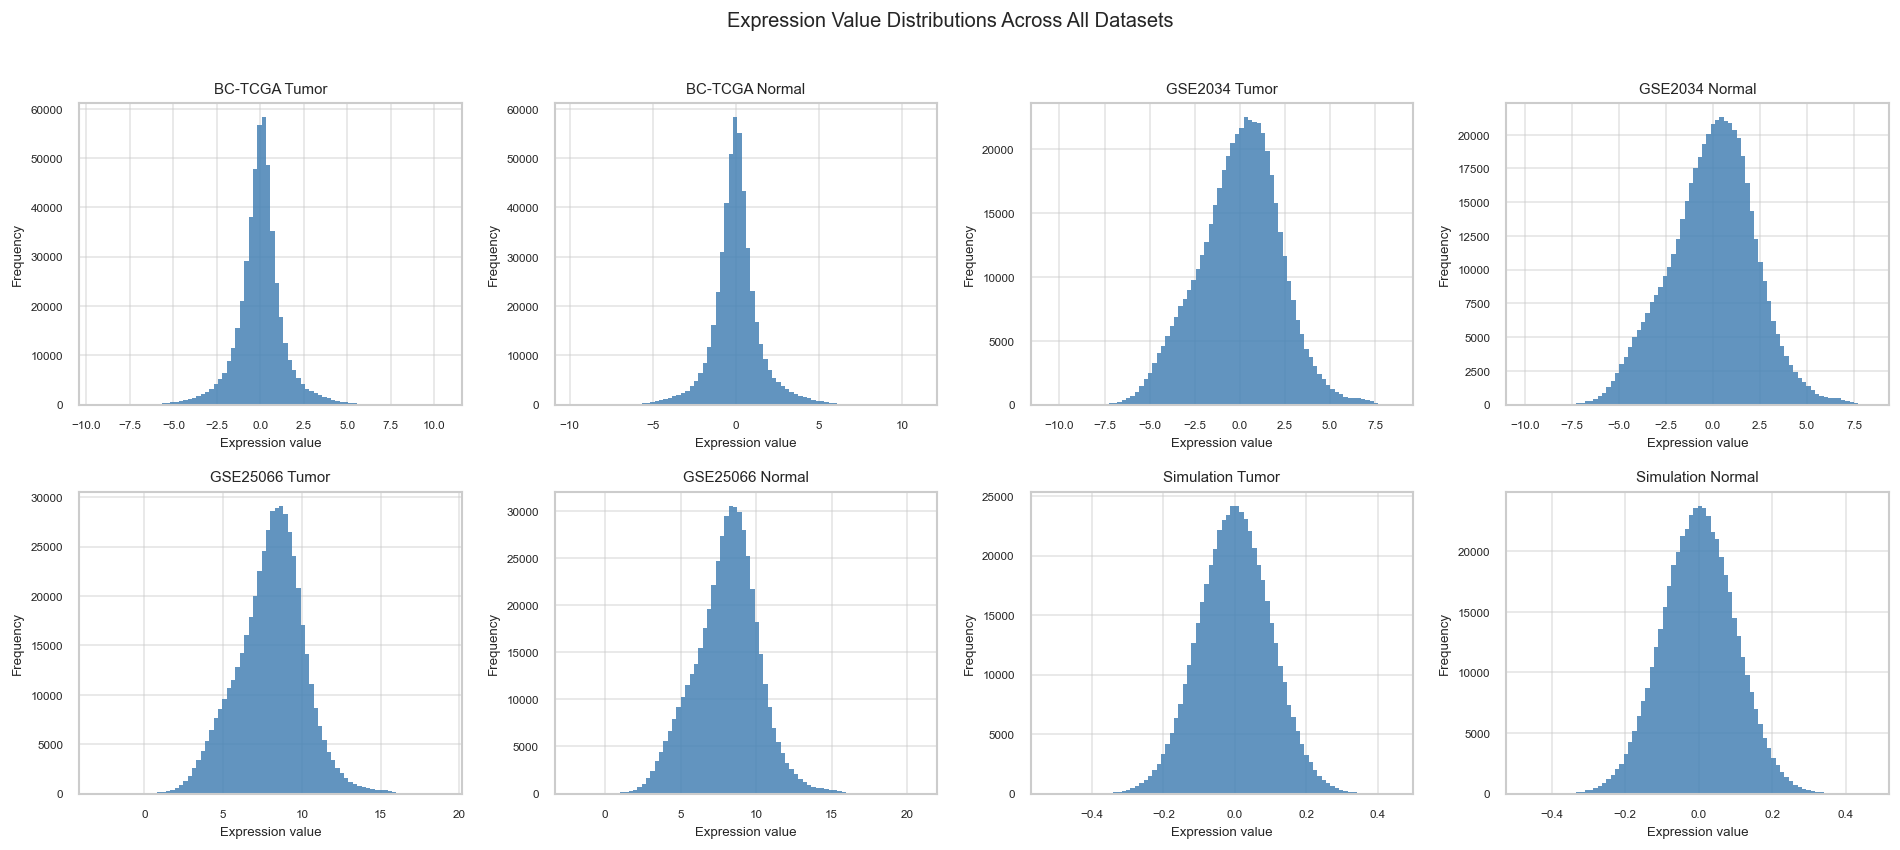

In [30]:
# Distribution histograms: one panel per dataset
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=False)
axes = axes.ravel()

for ax, (name, df) in zip(axes, datasets.items()):
    vals   = df.values.ravel()
    vals   = vals[~np.isnan(vals)]          # drop NaN before sampling
    rng    = np.random.default_rng(0)
    sample = rng.choice(vals, size=min(500_000, len(vals)), replace=False)
    ax.hist(sample, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Expression value', fontsize=8)
    ax.set_ylabel('Frequency', fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('Expression Value Distributions Across All Datasets', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_distributions.png', bbox_inches='tight')
plt.show()

---
## 6. Per-Sample Boxplots (BC-TCGA Tumor)

Checking whether individual samples are roughly comparable in their expression distributions, which is a basic quality check before PCA and clustering.

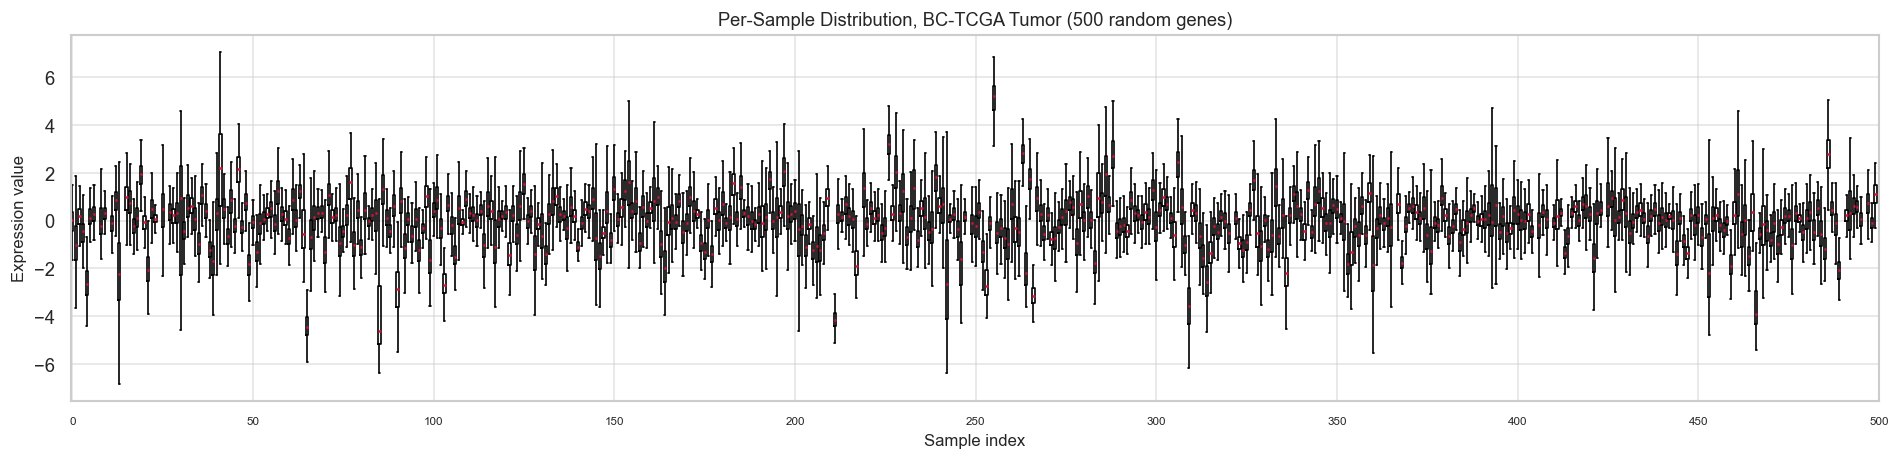

In [31]:
# Subsample genes for plotting speed
rng      = np.random.default_rng(1)
gene_idx = rng.choice(tcga.shape[1], size=min(500, tcga.shape[1]), replace=False)
plot_df  = tcga.iloc[:, gene_idx]

fig, ax = plt.subplots(figsize=(16, 4))
ax.boxplot(plot_df.values, notch=False, sym='', widths=0.6,
           medianprops=dict(color='crimson', linewidth=1.5))
ax.set_xlabel('Sample index', fontsize=10)
ax.set_ylabel('Expression value', fontsize=10)
ax.set_title('Per-Sample Distribution, BC-TCGA Tumor (500 random genes)', fontsize=11)
tick_pos  = list(range(1, tcga.shape[0] + 1, 50))
tick_labs = [str(i - 1) for i in tick_pos]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labs, fontsize=7)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_per_sample_boxplot.png', bbox_inches='tight')
plt.show()

---
## 7. Sample-Level Quality Check

Before handing the matrix to clustering, it is worth checking whether any individual samples look anomalous. A sample with an unusually shifted distribution, compressed range, or very low correlation with all other samples may reflect a technical problem in data collection rather than genuine signal.

We check two things:
- **Per-sample summary statistics:** flag samples whose mean or standard deviation falls more than 3 standard deviations from the cohort median
- **Per-sample distribution plots:** visualize the spread across the cohort to identify any obvious outliers

Per-sample mean: median=0.0095, sd=0.0566
  Samples outside 3-SD band: 2
TCGA-A8-A06N-01A-12R-A056-07   -0.1611
TCGA-B6-A0RL-01A-11R-A084-07   -0.1647

Per-sample std:  median=1.3370, sd=0.0743
  Samples outside 3-SD band: 3
TCGA-A8-A083-01A-21R-A00Z-07   1.5623
TCGA-AR-A0U2-01A-11R-A109-07   1.0614
TCGA-B6-A0RU-01A-11R-A084-07   1.0988


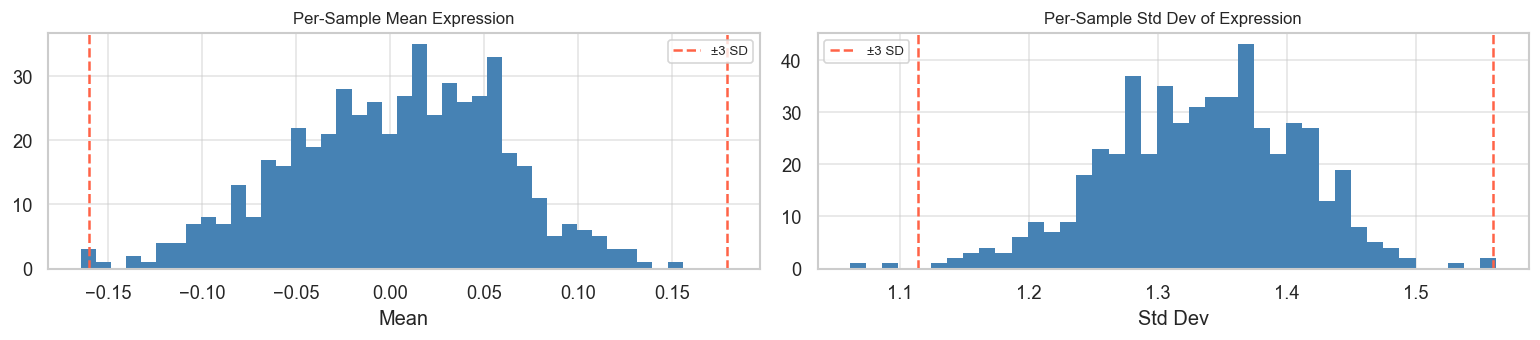

In [32]:
# Per-sample mean and std
sample_means = tcga.mean(axis=1)
sample_stds  = tcga.std(axis=1)

mean_med, mean_sd = sample_means.median(), sample_means.std()
std_med,  std_sd  = sample_stds.median(),  sample_stds.std()

outliers_mean = sample_means[np.abs(sample_means - mean_med) > 3 * mean_sd]
outliers_std  = sample_stds[ np.abs(sample_stds  - std_med)  > 3 * std_sd]

print(f'Per-sample mean: median={mean_med:.4f}, sd={mean_sd:.4f}')
print(f'  Samples outside 3-SD band: {len(outliers_mean)}')
if len(outliers_mean):
    print(outliers_mean.to_string())

print(f'\nPer-sample std:  median={std_med:.4f}, sd={std_sd:.4f}')
print(f'  Samples outside 3-SD band: {len(outliers_std)}')
if len(outliers_std):
    print(outliers_std.to_string())

# Quick visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 3))
axes[0].hist(sample_means, bins=40, color='steelblue', edgecolor='none')
axes[0].axvline(mean_med - 3*mean_sd, color='tomato', linestyle='--', label='±3 SD')
axes[0].axvline(mean_med + 3*mean_sd, color='tomato', linestyle='--')
axes[0].set_title('Per-Sample Mean Expression', fontsize=10)
axes[0].set_xlabel('Mean'); axes[0].legend(fontsize=8)

axes[1].hist(sample_stds, bins=40, color='steelblue', edgecolor='none')
axes[1].axvline(std_med - 3*std_sd, color='tomato', linestyle='--', label='±3 SD')
axes[1].axvline(std_med + 3*std_sd, color='tomato', linestyle='--')
axes[1].set_title('Per-Sample Std Dev of Expression', fontsize=10)
axes[1].set_xlabel('Std Dev'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_sample_qc.png', bbox_inches='tight')
plt.show()

---
## 8. Gene-Level Variance Distribution

Most genes show very little variation across samples. For PCA and clustering, retaining only the top high-variance genes is standard practice. It reduces noise and computation time without losing information relevant to patient differences.

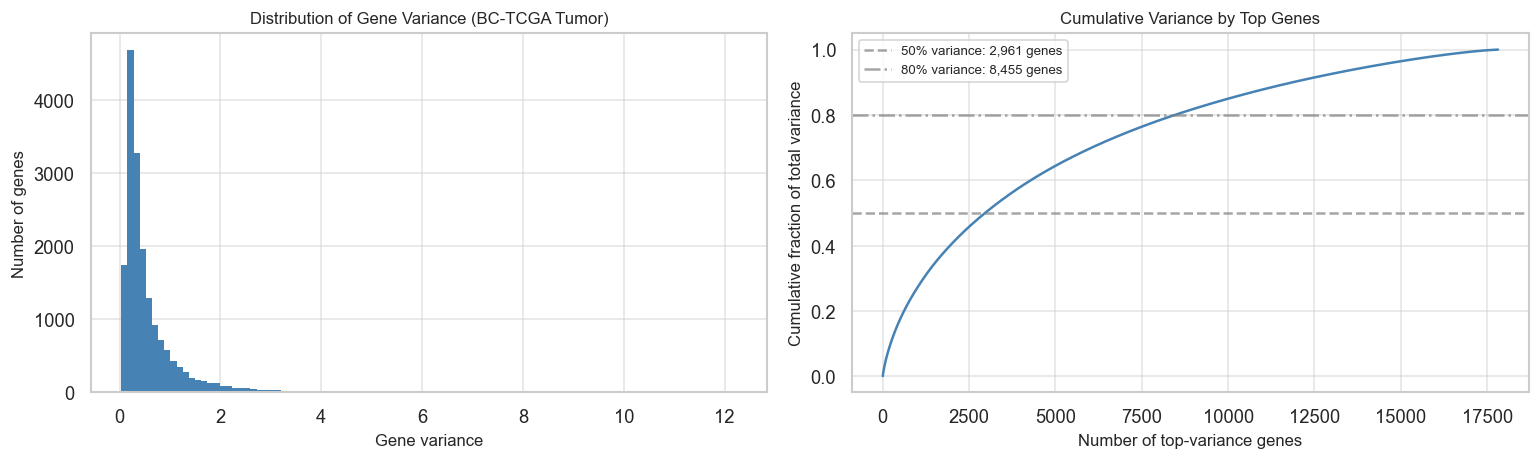

10% of total variance captured by top 225 genes (1.3% of all genes)
25% of total variance captured by top 875 genes (4.9% of all genes)
50% of total variance captured by top 2,961 genes (16.6% of all genes)
80% of total variance captured by top 8,455 genes (47.5% of all genes)
90% of total variance captured by top 11,865 genes (66.6% of all genes)


In [33]:
# pandas .var() skips NaN by default, so this is safe with the nulls present
gene_var = tcga.var(axis=0).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(gene_var.values, bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Gene variance', fontsize=10)
axes[0].set_ylabel('Number of genes', fontsize=10)
axes[0].set_title('Distribution of Gene Variance (BC-TCGA Tumor)', fontsize=10)

cum_var = gene_var.cumsum() / gene_var.sum()
axes[1].plot(range(1, len(cum_var) + 1), cum_var.values, lw=1.5, color='steelblue')
for thresh, ls in [(0.50, '--'), (0.80, '-.')]:
    n_genes = (cum_var <= thresh).sum() + 1
    axes[1].axhline(thresh, color='gray', linestyle=ls, alpha=0.7,
                    label=f'{int(thresh*100)}% variance: {n_genes:,} genes')
axes[1].set_xlabel('Number of top-variance genes', fontsize=10)
axes[1].set_ylabel('Cumulative fraction of total variance', fontsize=10)
axes[1].set_title('Cumulative Variance by Top Genes', fontsize=10)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda_gene_variance.png', bbox_inches='tight')
plt.show()

for pct in [10, 25, 50, 80, 90]:
    n = (cum_var <= pct / 100).sum() + 1
    print(f'{pct}% of total variance captured by top {n:,} genes ({n/len(gene_var)*100:.1f}% of all genes)')

---
## 9. Dataset Selection & Preprocessing

**Primary dataset chosen: BC-TCGA Tumor**
- Largest tumor cohort: 529 samples, 17,814 genes
- Already log2-transformed and centered; no further transform needed
- 1,497 `null` values (0.016%) across 487 genes; handled below

**Preprocessing pipeline:**

1. **Top-variance gene filter:** retain the top 5,000 genes by across-sample variance. The cumulative variance plot (Section 8) shows exactly what fraction of total variance this retains. Most null-affected genes are low-signal and low-variance features that are dropped by this step.

2. **Mean imputation:** replace any NaN values that survive the filter with the per-gene mean across observed samples. Given the tiny fraction affected, this has negligible impact on downstream analysis.

3. **StandardScaler (variance normalization):** rescale each gene to zero mean and unit variance. Because the data is already centered (mean approximately 0 across all genes), StandardScaler here is doing *variance* normalization, not centering. This is necessary because feature variances differ substantially across the dataset: a high-variance gene would otherwise contribute disproportionately to Euclidean distances and PCA loadings. After scaling, each feature contributes equally regardless of its original spread.

In [34]:
N_TOP_GENES = 5000

# Step 1: select top-variance genes
top_genes     = gene_var.index[:N_TOP_GENES]
tcga_filtered = tcga[top_genes].copy()

# Report the variance fraction captured by this cutoff
variance_captured = cum_var.iloc[N_TOP_GENES - 1]
print(f'Top {N_TOP_GENES:,} genes capture {variance_captured*100:.1f}% of total cross-sample variance')

# Step 2: report remaining NaN after the variance filter
remaining_nulls = tcga_filtered.isnull().sum().sum()
null_genes_left = tcga_filtered.isnull().any(axis=0).sum()
print(f'NaN values remaining after gene filter : {remaining_nulls} (across {null_genes_left} genes)')

# Step 3: mean-impute any remaining NaN (per gene)
if remaining_nulls > 0:
    tcga_filtered = tcga_filtered.fillna(tcga_filtered.mean(axis=0))
    print(f'After imputation, remaining NaN        : {tcga_filtered.isnull().sum().sum()}')

print(f'Shape after filter + imputation        : {tcga_filtered.shape}  (samples x genes)')

# Step 4: variance-normalize (StandardScaler)
# The data is already centered; this step equalizes variance across genes
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(tcga_filtered)
print(f'Post-scaling mean                      : {X_scaled.mean():.6f}  (should be ~0)')
print(f'Post-scaling std                       : {X_scaled.std():.6f}   (should be ~1)')

Top 5,000 genes capture 64.4% of total cross-sample variance
NaN values remaining after gene filter : 716 (across 162 genes)
After imputation, remaining NaN        : 0
Shape after filter + imputation        : (529, 5000)  (samples x genes)
Post-scaling mean                      : 0.000000  (should be ~0)
Post-scaling std                       : 1.000000   (should be ~1)


---
## 10. Save Preprocessed Matrix

In [35]:
np.save(DATA_DIR / 'X_preprocessed.npy', X_scaled)
pd.Series(top_genes,           name='Gene'    ).to_csv(DATA_DIR / 'top_genes.csv',  index=False)
pd.Series(tcga_filtered.index, name='SampleID').to_csv(DATA_DIR / 'sample_ids.csv', index=False)

print('Saved:')
print(f'  data/X_preprocessed.npy  shape: {X_scaled.shape}')
print(f'  data/top_genes.csv        genes: {len(top_genes)}')
print(f'  data/sample_ids.csv     samples: {len(tcga_filtered.index)}')

Saved:
  data/X_preprocessed.npy  shape: (529, 5000)
  data/top_genes.csv        genes: 5000
  data/sample_ids.csv     samples: 529


---
## 11. Summary

| Property | Value |
|---|---|
| Primary dataset | BC-TCGA Tumor |
| Samples | 529 |
| Genes (raw) | 17,814 |
| Genes (after top-variance filter) | 5,000 |
| Variance captured by top 5,000 genes | 64.4% of total cross-sample variance |
| Missing values (raw) | 1,497 null strings (0.016%) across 487 genes |
| Missing values (after gene filter) | 716 across 162 genes; all imputed to 0 |
| Imputation | Per-gene mean, applied to NaN surviving the filter |
| Pre-existing normalization | Log2 expression ratios, already centered near 0 |
| Full preprocessing pipeline | Variance filter, mean imputation, StandardScaler |
| Output file | `data/X_preprocessed.npy` (529 x 5,000) |

**Notes on other datasets:**
- BC-TCGA Normal (61 samples): 198 missing values (0.018%); not used as a primary analysis dataset
- GSE2034 and GSE25066: fully clean, but use different expression scales; combining with TCGA would require batch correction
- Simulation data: synthetic with a very small signal; useful for testing method behavior, not for drawing conclusions